In [1]:
"""
Maxwell.Cook@colostate.edu
"""

import os, sys

# import the __functions.py (custom functions)
sys.path.append(os.getcwd()) # add code folder to system path
from __functions import *  # imports all custom functions

# directories
# use the current working directory
projdir = Path.cwd().parents[1] # moves up two, outside code directory
print(f"Project directory set to: {projdir}")

print("Success !")

Project directory set to: /Users/mcc/Library/CloudStorage/Box-Box/CFRI/RADS/TEALOM
Success !


In [3]:
# load the treatment data
fp = os.path.join(projdir, r"data/spatial/treatments/NCFC/NCFC_FT_treatments_from2022.gpkg")
trts = gpd.read_file(fp)
trts.head()

,OBJECTID,PRJ_NAME,AGENCY,AGENCY_C,FUNDING,LANDOWNER,MGT_TYPE,RXFIRE_MGT,CANOPY_MGT,SURF_MGT,...,NOTES,ORGFILE,UPDATED,MODIFY_BY,FOR_TYPE,Shape__Area,Shape__Length,CanEff,SurfEff,geometry
0,1034,DR311_Strawberry Hand Thin Pile,Bureau of Land Management,BLM,,Federal (BLM),SURFACE,,,Pile Fuels,...,,BLM CO Completed Vegetation Treatments Polygons,1717113600000,S E Mueller,Lodgepole Pine,4.971043e+05,14971.919858,None,Manage,"MULTIPOLYGON (((428540.363 4434074.647, 428543..."
1,1042,1_Bellyache Piling,Bureau of Land Management,BLM,,Federal (BLM),SURFACE,,,Pile Fuels,...,,BLM CO Completed Vegetation Treatments Polygons,1717113600000,S E Mueller,Lodgepole Pine,9.018690e+04,1416.619312,None,Manage,"MULTIPOLYGON (((356464.794 4391260.674, 356449..."
2,1157,BIL312_CA_Acres_Treated,Bureau of Land Management,BLM,,Private,SURFACE,,,Mulching,...,,BLM CO Completed Vegetation Treatments Polygons,1717113600000,S E Mueller,Hardwood,4.021354e+06,96266.935685,None,Masticate,"MULTIPOLYGON (((340374.181 4463395.86, 340378...."
3,7042,None,Colorado State Forest Service,CSFS,SFA,Private,CANOPY,,Mechanical,,...,,WebDET/SMART,1725926400000,RDannels,Ponderosa Pine,1.092857e+04,500.884111,Mech Thin,None,"MULTIPOLYGON (((470780.42 4437546.81, 470811.0..."
4,11622,BLM Harvest area,Colorado State Forest Service,CSFS,Good Neighbor Authority,Federal (BLM),CANOPY,,Mechanical,,...,Forest Stand Improvement,GEOTRACKS_2023_Completed_ForestManagementTreat...,1725926400000,RDannels,Lodgepole Pine,1.154463e+05,1645.717611,Mech Thin,None,"MULTIPOLYGON (((380824.283 4474222.713, 380824..."


## Create an ignitions grid from the FPA-FOD

Get FPA-FOD ignitions from the RMA Dashboard and convert to a binary ASCII grid for the MTT runs.

In [4]:
# gather ignition data for MTT runs
# define the area of interest
fp = Path(os.path.join(projdir, 'data/spatial/boundaries/NCFC_project_area.gpkg'))
aoi = gpd.read_file(fp).to_crs('EPSG:4326')  # ensure it's in lat/lon for web mapping

# REST URL for the FPA FOD from the RMA Dashboard
url = 'https://apps.fs.usda.gov/arcx/rest/services/EDW/EDW_FireOccurrence6thEdition_01/MapServer'
# request the points within our AOI
fpa_fod = get_feature_service_gdf(url, geo=aoi, layer=29) # FPA is layer 29
print(f"Found [{len(fpa_fod)}] ignitions in the study region (total).")
print(f"\nColumns:\n{fpa_fod.columns}")

,geometry,OBJECTID,FOD_ID,FPA_ID,SOURCE_SYSTEM_TYPE,SOURCE_SYSTEM,NWCG_REPORTING_AGENCY,NWCG_REPORTING_UNIT_ID,NWCG_REPORTING_UNIT_NAME,SOURCE_REPORTING_UNIT,...,CONT_TIME,FIRE_SIZE,FIRE_SIZE_CLASS,LATITUDE,LONGITUDE,OWNER_DESCR,STATE,COUNTY,FIPS_CODE,FIPS_NAME
0,POINT (-106.74221 40.3811),11278,11330,FS-1439059,FED,FS-FIRESTAT,FS,USWYMRF,"Medicine Bow-Routt National Forests, Thunder B...",0211,...,1400,0.1,A,40.381111,-106.742222,USFS,CO,107,08107,Routt County
1,POINT (-106.69777 39.48583),12514,12569,FS-1440734,FED,FS-FIRESTAT,FS,USCOWRF,White River National Forest,0215,...,1912,0.2,A,39.485833,-106.697778,USFS,CO,None,None,None
2,POINT (-106.66749 40.47916),17136,17220,FS-1446538,FED,FS-FIRESTAT,FS,USWYMRF,"Medicine Bow-Routt National Forests, Thunder B...",0211,...,1600,0.1,A,40.479167,-106.667500,USFS,CO,107,08107,Routt County
3,POINT (-106.8211 41.00638),28760,28904,FS-1461238,FED,FS-FIRESTAT,FS,USWYMRF,"Medicine Bow-Routt National Forests, Thunder B...",0206,...,1230,0.1,A,41.006389,-106.821111,USFS,WY,7,56007,Carbon County
4,POINT (-106.73888 40.18833),33033,33199,FS-1473876,FED,FS-FIRESTAT,FS,USWYMRF,"Medicine Bow-Routt National Forests, Thunder B...",0211,...,1600,5.5,B,40.188333,-106.738889,USFS,CO,107,08107,Routt County
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,POINT (-105.03622 39.82011),2267662,400610386,SFO-2020190004974,NONFED,ST-NASF,ST/C&L,USCOWESX,Westminster Fire Department,190,...,1713,0.1,A,39.820114,-105.036235,MISSING/NOT SPECIFIED,CO,ADAMS,08001,Adams County
79,POINT (-105.03473 39.9871),2273727,400617285,SFO-20201801004173,NONFED,ST-NASF,ST/C&L,USCONMIX,North Metro Fire Rescue District,180,...,0547,0.1,A,39.987109,-105.034743,PRIVATE,CO,None,None,None
80,POINT (-105.04072 39.78985),2280204,400624673,SFO-20201601027048,NONFED,ST-NASF,ST/C&L,USCODENX,Denver Fire Department,1601,...,2102,0.1,A,39.789860,-105.040729,PRIVATE,CO,DENVER,08031,Denver County
81,POINT (-105.04016 39.9476),2280222,400624692,SFO-20201801002015,NONFED,ST-NASF,ST/C&L,USCONMIX,North Metro Fire Rescue District,180,...,1459,0.1,A,39.947611,-105.040174,PRIVATE,CO,None,None,None


In [7]:
# filter to within Xkm of a treatment polygon
fpa_fod.to_crs(trts.crs, inplace=True)
# buffer treatments
trtsB = trts.copy()
trtsB['geometry'] = trtsB.geometry.buffer(10000)

# find ignitions
igns = gpd.sjoin(fpa_fod, trtsB, predicate="within", how="inner")
igns.drop(columns=["index_right"], inplace=True)

print(f"Found [{len(igns)}] ignitions.")
print("\n",igns.columns,"\n")
print(igns['FIRE_SIZE_CLASS'].unique())
print(igns.groupby('FIRE_SIZE_CLASS')['FIRE_SIZE'].mean())

Found [158113] ignitions.

 Index(['geometry', 'OBJECTID_left', 'FOD_ID', 'FPA_ID', 'SOURCE_SYSTEM_TYPE',
       'SOURCE_SYSTEM', 'NWCG_REPORTING_AGENCY', 'NWCG_REPORTING_UNIT_ID',
       'NWCG_REPORTING_UNIT_NAME', 'SOURCE_REPORTING_UNIT',
       'SOURCE_REPORTING_UNIT_NAME', 'LOCAL_FIRE_REPORT_ID',
       'LOCAL_INCIDENT_ID', 'FIRE_CODE', 'FIRE_NAME',
       'ICS_209_PLUS_INCIDENT_JOIN_ID', 'ICS_209_PLUS_COMPLEX_JOIN_ID',
       'MTBS_ID', 'MTBS_FIRE_NAME', 'COMPLEX_NAME', 'FIRE_YEAR',
       'DISCOVERY_DATE', 'DISCOVERY_DOY', 'DISCOVERY_TIME',
       'NWCG_CAUSE_CLASSIFICATION', 'NWCG_GENERAL_CAUSE',
       'NWCG_CAUSE_AGE_CATEGORY', 'CONT_DATE', 'CONT_DOY', 'CONT_TIME',
       'FIRE_SIZE', 'FIRE_SIZE_CLASS', 'LATITUDE', 'LONGITUDE', 'OWNER_DESCR',
       'STATE', 'COUNTY', 'FIPS_CODE', 'FIPS_NAME', 'OBJECTID_right',
       'PRJ_NAME', 'AGENCY', 'AGENCY_C', 'FUNDING', 'LANDOWNER', 'MGT_TYPE',
       'RXFIRE_MGT', 'CANOPY_MGT', 'SURF_MGT', 'REFOREST', 'TREE_COUNT',
       'SPECIES', 

In [8]:
# retain only ignitions above the C size class
igns_large = igns[~igns['FIRE_SIZE_CLASS'].isin(['A','B'])]
len(igns_large)

3092

In [10]:
# only within the project area
igns_large_aoi = gpd.sjoin(igns_large, aoi.to_crs(igns_large.crs), predicate="within", how="inner")
len(igns_large_aoi)

2779

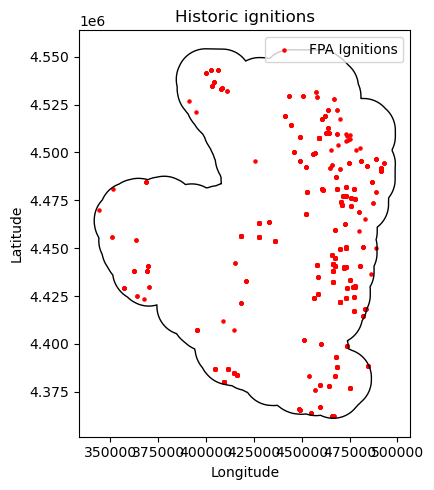

In [11]:
# static plot of ignition locations
aoi = aoi.to_crs(igns_large.crs) # match CRS
fig, ax = plt.subplots(figsize=(6, 5))
igns_large_aoi.plot(ax=ax, color='red', markersize=5, label='FPA Ignitions')
aoi.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1)
ax.set_title("Historic ignitions")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
# save the spatial points
gdf = igns_large[['FOD_ID','FPA_ID','FIRE_SIZE_CLASS','geometry']]
gdf = gdf.rename(columns={'FIRE_SIZE_CLASS': 'size_class'})
gdf = gdf.to_crs('EPSG:26913') # match the fuelscape
ign_pt_fp = os.path.join(projdir, 'data/spatial/flammap/ignitions.shp')
gdf.to_file(ign_pt_fp)
print(f"Saved ignition points to: {ign_pt_fp}")
del gdf

Saved ignition points to: /Users/mcc/Library/CloudStorage/Box-Box/CFRI/RADS/TEALOM/data/spatial/flammap/ignitions.shp


In [ ]:
# # create and save an ignitions ASCII file for the MTT run
# pre_fuelscape = list_files(projdir, "fuelscape_baseline.tif", recursive=True)[0] # to match
# ign_ascii_fp = os.path.join(projdir, 'data/spatial/flammap/ignitions.asc')
# create_ignition_ascii(igns_large, pre_fuelscape, ign_ascii_fp) # see __functions.py

In [ ]:
del fpa_fod